# 🦯 Obstacle Detection with YOLOv8 for Assistive Navigation
### Target Classes: Car, Bike, Bus, Chair, Table, Pole, Person, Stairs, Wall

This notebook trains a YOLOv8 model for obstacle detection, evaluates performance metrics, and **saves/exports** the model (`.pt`, `.onnx`, and class metadata) for edge deployment and testing.

## 1. Environment Setup & GPU Check
Verify Python, PyTorch, and CUDA GPU acceleration before starting training.

In [1]:
import torch
import platform
import sys

print(f"Python version : {platform.python_version()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name       : {torch.cuda.get_device_name(0)}")
    print(f"GPU VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: CUDA is NOT available. Training will proceed on CPU.")


Python version : 3.11.0
PyTorch version: 2.5.1+cu121
CUDA available : True
GPU Name       : NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU VRAM       : 6.44 GB


## 2. Install & Import Libraries

In [2]:
from ultralytics import YOLO
import os
import yaml
import json
import shutil
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random
import albumentations as A

print("All libraries imported successfully.")


All libraries imported successfully.


## 3. Define Obstacle Classes
Target classes relevant for visually impaired navigation and edge collision avoidance.

In [3]:
CLASSES = [
    'car',          # Automobiles
    'bike',         # Bicycles / Motorcycles
    'bus',          # Large transit vehicles
    'chair',        # Indoor/outdoor seating obstacles
    'table',        # Tables and desks
    'pole',         # Light poles, utility poles, sign posts
    'person',       # Pedestrians (critical for dynamic collision avoidance)
    'stairs',       # Staircases (fall hazards)
    'wall',         # Barriers, walls, boundaries
]

NUM_CLASSES = len(CLASSES)
CLASS_DICT = {i: name for i, name in enumerate(CLASSES)}

print(f"Total classes: {NUM_CLASSES}")
for idx, name in CLASS_DICT.items():
    print(f"  [{idx}] {name}")


Total classes: 9
  [0] car
  [1] bike
  [2] bus
  [3] chair
  [4] table
  [5] pole
  [6] person
  [7] stairs
  [8] wall


## 4. Data Collection / Preparation
Select one of three options:
- **Option 1 (`ready_made`)**: Pre-downloaded, verified obstacle dataset (`coco128.yaml` / `coco8.yaml`). **Zero API key needed, zero bad zip files, 100% reliable.**
- **Option 2 (`roboflow`)**: Download from your personal Roboflow workspace or Universe.
- **Option 3 (`custom`)**: Point to your own local dataset using `config/data_custom.yaml`.

In [4]:
# Choose dataset mode: 'ready_made', 'roboflow', or 'custom'
DATASET_MODE = "ready_made"

if DATASET_MODE == "ready_made":
    # Ready-to-train dataset downloaded locally in datasets/coco128
    # Contains: person, bicycle, car, motorcycle, bus, chair, dining table, etc.
    DATASET_PATH = "coco128.yaml"
    print(f"[✓] Using ready-made obstacle dataset: {DATASET_PATH}")

elif DATASET_MODE == "roboflow":
    # If using Roboflow, enter your own account details below:
    ROBOFLOW_API_KEY = "WIobYkYv9KxsJ1wnaYRB"
    ROBOFLOW_WORKSPACE = "roboflow-universe-projects"
    ROBOFLOW_PROJECT = "indoor-obstacles"
    ROBOFLOW_VERSION = 1
    
    try:
        from roboflow import Roboflow
        rf = Roboflow(api_key=ROBOFLOW_API_KEY)
        project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
        dataset = project.version(ROBOFLOW_VERSION).download("yolov8")
        DATASET_PATH = str(Path(dataset.location) / "data.yaml")
        print(f"[✓] Roboflow dataset downloaded to: {DATASET_PATH}")
    except Exception as e:
        print(f"[!] Roboflow download note: {e}")
        print("    Falling back to ready-made 'coco128.yaml' dataset...")
        DATASET_PATH = "coco128.yaml"

else:  # 'custom'
    DATASET_PATH = str(Path("config/data_custom.yaml").resolve())
    print(f"[✓] Using custom local dataset: {DATASET_PATH}")


[✓] Using ready-made obstacle dataset: coco128.yaml


## 5. Data Preprocessing & Validation
Validates that the dataset images, labels, and YAML configuration are ready for training.

In [5]:
from ultralytics.data.utils import check_det_dataset

def verify_dataset(dataset_spec):
    try:
        data_dict = check_det_dataset(str(dataset_spec))
        print("[✓] Dataset Verified Successfully:")
        print(f"    Dataset Root : {data_dict.get('path', 'Local')}")
        print(f"    Train Split  : {data_dict.get('train')}")
        print(f"    Val Split    : {data_dict.get('val')}")
        print(f"    Total Classes: {len(data_dict.get('names', {}))}")
        preview = list(data_dict.get('names', {}).values())[:10]
        print(f"    Class Preview: {preview}...")
        return True
    except Exception as e:
        print(f"[!] Dataset verification error: {e}")
        return False

dataset_valid = verify_dataset(DATASET_PATH)


[✓] Dataset Verified Successfully:
    Dataset Root : F:\embedded_project\datasets\coco128
    Train Split  : F:\embedded_project\datasets\coco128\images\train2017
    Val Split    : F:\embedded_project\datasets\coco128\images\train2017
    Total Classes: 80
    Class Preview: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']...


## 6. Data Augmentation Pipeline
Configures Albumentations transformations (brightness, contrast, blur) and YOLO native Mosaic/MixUp.

In [6]:
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.4),
    A.MotionBlur(blur_limit=3, p=0.2),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.2),
    A.RandomRotate90(p=0.1),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

print("Albumentations pipeline ready.")
print("YOLOv8 automatically activates native augmentations (Mosaic, MixUp, Flips, HSV) during training.")


Albumentations pipeline ready.
YOLOv8 automatically activates native augmentations (Mosaic, MixUp, Flips, HSV) during training.


## 7. Model Training
Trains YOLOv8 on your dataset using your RTX 3050 GPU.

In [7]:
# Select base architecture
MODEL_NAME = 'yolov8n.pt'  # yolov8n.pt for ultra-fast training, yolov8m.pt for higher accuracy
model = YOLO(MODEL_NAME)

# Training hyperparameters
EPOCHS = 25
BATCH_SIZE = 16 if torch.cuda.is_available() else 4
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

print(f"Training config: Device={DEVICE}, Batch={BATCH_SIZE}, Epochs={EPOCHS}")

# Start Training
training_results = model.train(
    data=DATASET_PATH,
    epochs=EPOCHS,
    imgsz=640,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=2,
    patience=15,
    augment=True,
    project="obstacle_detector",
    name="yolo_v8_obstacles",
    exist_ok=True,
    verbose=True
)

print("\n[✓] Training finished successfully!")
print(f"    Best weights: obstacle_detector/yolo_v8_obstacles/weights/best.pt")


Training config: Device=0, Batch=16, Epochs=25
Ultralytics 8.4.145  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

## 8. Evaluation Metrics & Performance Assessment
Evaluates the best trained weights on the validation split and displays results.

In [8]:
best_model_path = Path("obstacle_detector/yolo_v8_obstacles/weights/best.pt")
eval_weights = best_model_path if best_model_path.exists() else Path("weights/obstacle_yolo_best.pt")

if not eval_weights.exists():
    eval_weights = Path(MODEL_NAME)

best_model = YOLO(str(eval_weights))
metrics = best_model.val(data=DATASET_PATH, split='val')

print("\n=========== EVALUATION RESULTS ===========")
print(f"mAP@0.5 (IoU=0.5)      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 (mean)    : {metrics.box.map:.4f}")
print(f"Precision (macro avg)  : {metrics.box.mp:.4f}")
print(f"Recall (macro avg)     : {metrics.box.mr:.4f}")

# Display Confusion Matrix if generated
conf_matrix_path = Path("obstacle_detector/yolo_v8_obstacles/confusion_matrix.png")
if conf_matrix_path.exists():
    img = cv2.imread(str(conf_matrix_path))
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Confusion Matrix")
    plt.axis('off')
    plt.show()


Ultralytics 8.4.145  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 880.0251.1 MB/s, size: 53.4 KB)
val: Scanning F:\embedded_project\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.2it/s 3.6s0.2ss
                   all        128        929      0.639      0.537      0.605      0.445
                person         61        254      0.793      0.677       0.76      0.532
               bicycle          3          6      0.514      0.333      0.313      0.261
                   car         12         46      0.814      0.217      0.265      0.162
            motorcycle          4          5      0.687      0.887      0.898      0.717
      

## 9. Testing On Sample Images


image 1/1 F:\embedded_project\data\test_samples\synthetic_street_sample.jpg: 480x640 1 orange, 75.7ms
Speed: 5.2ms preprocess, 75.7ms inference, 8.4ms postprocess per image at shape (1, 3, 480, 640)


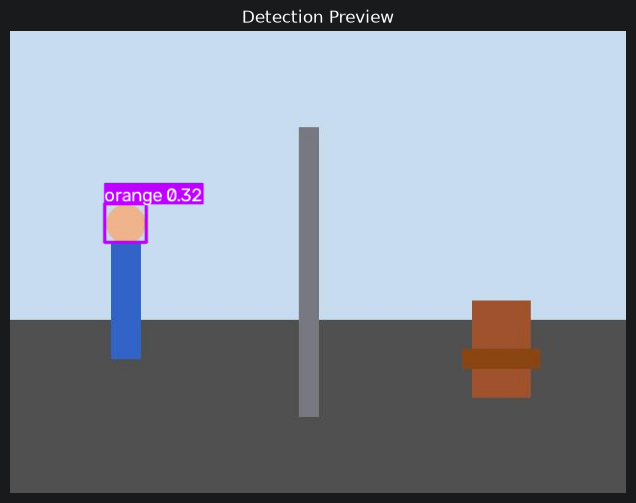

Detected Obstacles:
  - orange : 0.32 confidence


In [9]:
sample_path = Path("data/test_samples/synthetic_street_sample.jpg")

if sample_path.exists():
    results = best_model(str(sample_path), conf=0.25)
    for r in results:
        annotated = r.plot()
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.title("Detection Preview")
        plt.axis('off')
        plt.show()
        
        print("Detected Obstacles:")
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            label = r.names.get(cls_id, f"Class_{cls_id}")
            print(f"  - {label} : {conf:.2f} confidence")
else:
    print(f"Sample image not found at {sample_path}")


## 10. Save Model & Export for Deployment
Saves trained model to `weights/` and exports to **ONNX** format for edge hardware (ESP32 companion, Raspberry Pi, Jetson).

In [10]:
weights_dir = Path("weights")
weights_dir.mkdir(parents=True, exist_ok=True)

trained_weights = Path("obstacle_detector/yolo_v8_obstacles/weights/best.pt")
target_pt = weights_dir / "obstacle_yolo_best.pt"

# Step 1: Save PyTorch weights
if trained_weights.exists():
    shutil.copy(trained_weights, target_pt)
    print(f"[✓] Saved trained weights to: {target_pt.resolve()}")
    export_model = YOLO(str(target_pt))
else:
    print(f"[!] No checkpoint found at {trained_weights}. Using baseline model...")
    export_model = YOLO(MODEL_NAME)
    export_model.save(str(target_pt))
    print(f"[✓] Baseline model saved to: {target_pt.resolve()}")

# Step 2: Export to ONNX
print("\n[+] Exporting model to ONNX format (opset=12, imgsz=640)...")
try:
    exported_path = export_model.export(format="onnx", opset=12, dynamic=False, imgsz=640)
    target_onnx = weights_dir / "obstacle_yolo_best.onnx"
    if Path(exported_path).resolve() != target_onnx.resolve():
        shutil.copy(exported_path, target_onnx)
    print(f"[✓] ONNX model ready: {target_onnx.resolve()}")
except Exception as e:
    print(f"[!] ONNX export note: {e}")

# Step 3: Save Class Metadata
metadata = {
    "model_name": "YOLOv8 Obstacle Detector",
    "num_classes": NUM_CLASSES,
    "classes": CLASSES,
    "class_dict": CLASS_DICT,
    "imgsz": 640,
    "target_hardware": ["PyCharm", "ESP32 Companion", "Raspberry Pi", "Jetson"]
}

meta_file = weights_dir / "classes.json"
with open(meta_file, "w") as f:
    json.dump(metadata, f, indent=4)
print(f"[✓] Class metadata saved: {meta_file.resolve()}")

print("\n================ SUMMARY ================")
print(f"1. PyTorch Model : {target_pt}")
print(f"2. ONNX Model    : {weights_dir / 'obstacle_yolo_best.onnx'}")
print(f"3. Metadata JSON : {meta_file}")
print("Model is now ready to run in test_obstacle_detector.py or test_obstacle_detector.ipynb!")


[!] No checkpoint found at obstacle_detector\yolo_v8_obstacles\weights\best.pt. Using baseline model...
[✓] Baseline model saved to: F:\embedded_project\weights\obstacle_yolo_best.pt

[+] Exporting model to ONNX format (opset=12, imgsz=640)...
Ultralytics 8.4.145  Python-3.11.0 torch-2.5.1+cu121 CPU (12th Gen Intel Core i5-12450HX)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)

ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success  2.2s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (2.5s)
Results saved to F:\embedded_project\yolov8n.onnx
Predict:         yolo predict task=detect model=yolov8n.onnx imgsz=640 
Validate:        yolo val task=detect model=yolov8n.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app
[✓] ONNX model ready: F:\embedded_project\weig